In [1]:
import sys
sys.path.append("..")

import torch

from source.system import SystemParams
from source.policy import NeuralPolicy
from source.utils import read_csv

from source.training import train_net

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.diagnostics import check_energy_balance

from source.stochastic_processes import make_price_function
from source.simulation import rollout_trajectory
from source.plotting import (
    plot_state_trajectories,
    plot_control_trajectories,
    plot_endogenous_trajectories,
    plot_cost_trajectories,
)

In [2]:
EPOCHS = 20
BATCH_SIZE = 32

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:24]
future_price = energy_prices[24:]

policy = NeuralPolicy().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

[001] J_train=8.7483 | J_eval(det)=8.2767
[002] J_train=8.4728 | J_eval(det)=8.1762
[003] J_train=8.3776 | J_eval(det)=8.0758
[004] J_train=8.4479 | J_eval(det)=7.9780
[005] J_train=8.0211 | J_eval(det)=7.8830
[006] J_train=8.3324 | J_eval(det)=7.7889
[007] J_train=7.7896 | J_eval(det)=7.6939
[008] J_train=7.7848 | J_eval(det)=7.5946
[009] J_train=7.7975 | J_eval(det)=7.4970
[010] J_train=7.6237 | J_eval(det)=7.3993
[011] J_train=7.7480 | J_eval(det)=7.3002
[012] J_train=7.2646 | J_eval(det)=7.1999
[013] J_train=7.2976 | J_eval(det)=7.0995
[014] J_train=7.4064 | J_eval(det)=6.9977
[015] J_train=7.2024 | J_eval(det)=6.8958
[016] J_train=7.3879 | J_eval(det)=6.7950
[017] J_train=6.9668 | J_eval(det)=6.6968
[018] J_train=6.6932 | J_eval(det)=6.5989
[019] J_train=6.7370 | J_eval(det)=6.5122
[020] J_train=6.8172 | J_eval(det)=6.4259

Training ready in 14.1s. Epoch: 18. Best J=6.6932


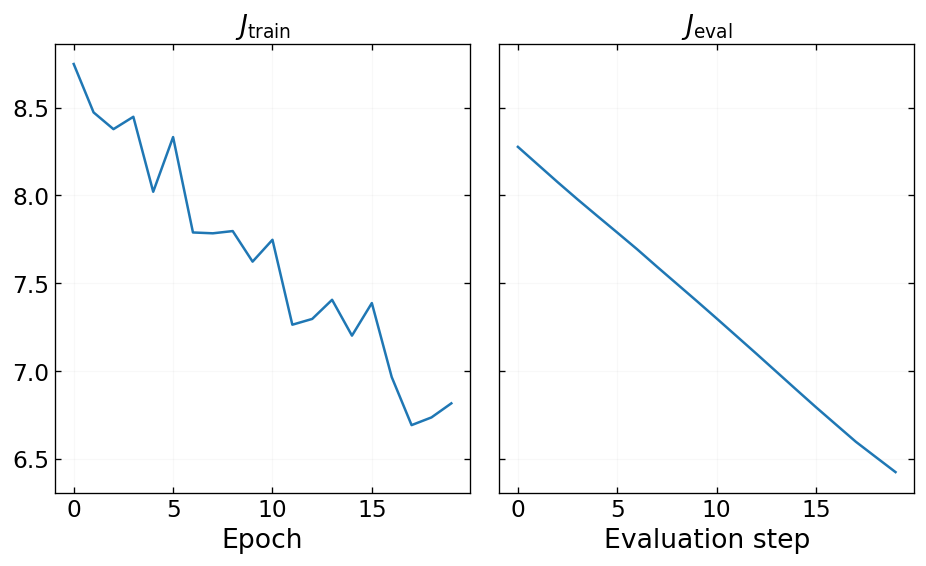

In [3]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)

ax[0].plot(res["J_train_hist"])
ax[0].set_title(r"$J_{\mathrm{train}}$")
ax[0].set_xlabel("Epoch")

ax[1].plot(res["J_eval_hist"])
ax[1].set_title(r"$J_{\mathrm{eval}}$")
ax[1].set_xlabel("Evaluation step")

plt.tight_layout()
plt.show()

In [4]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(20, 1)

history = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=1,
    device=DEVICE,
)
J_episode = history["J_episode"]
print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: 6.3523


In [5]:
check_energy_balance(history, dt=params.dt)

{'max_abs_error': 1.9073486328125e-06,
 'mean_abs_error': 1.948055938783e-09,
 'mean_Ub': 21.367904663085938,
 'max_Ub': 115.34107208251953}

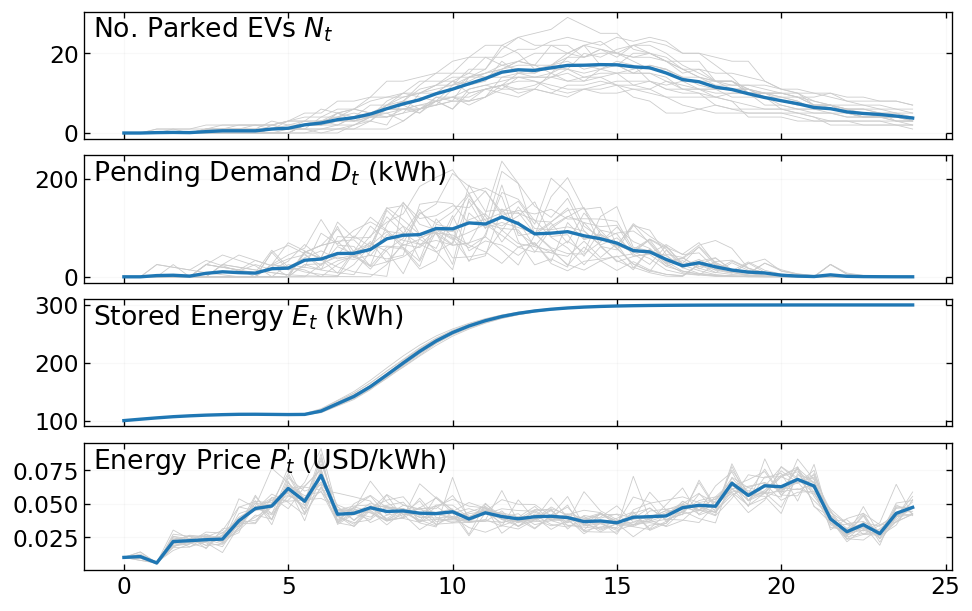

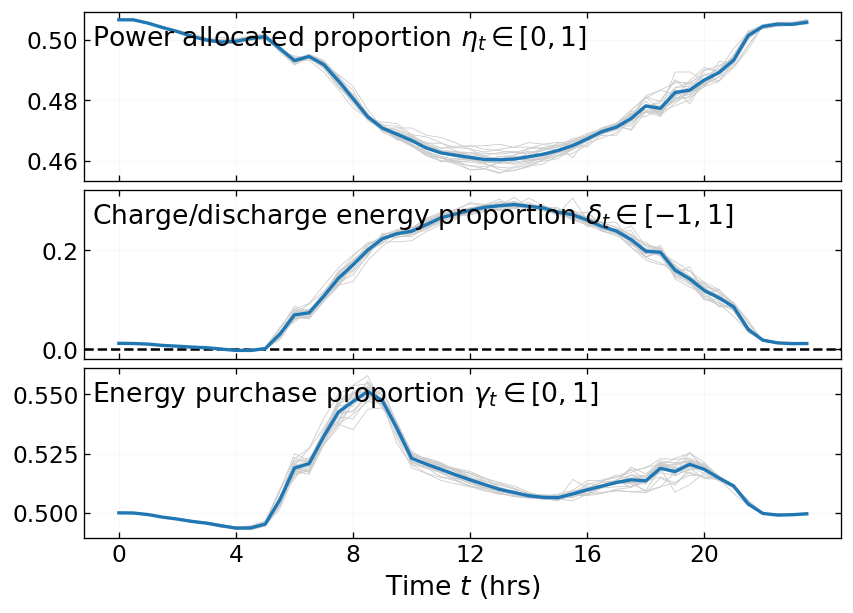

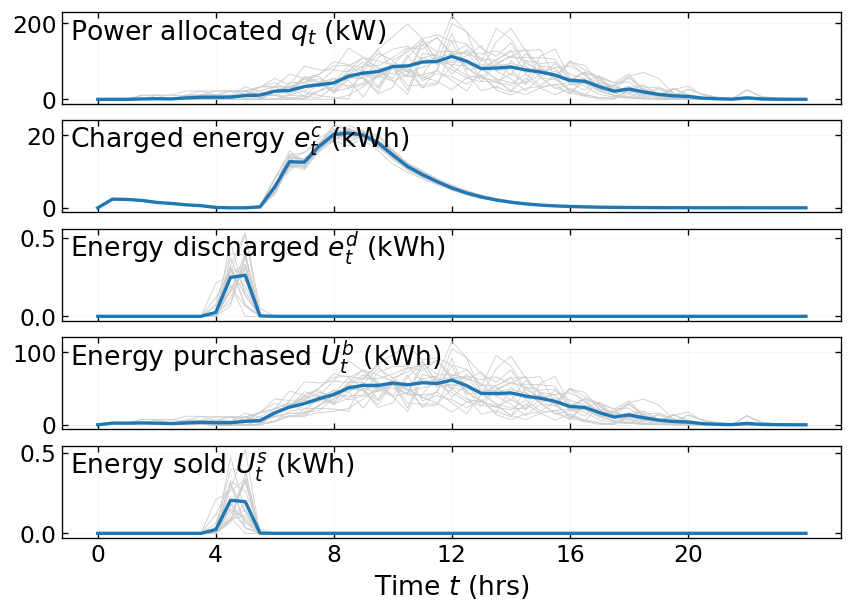

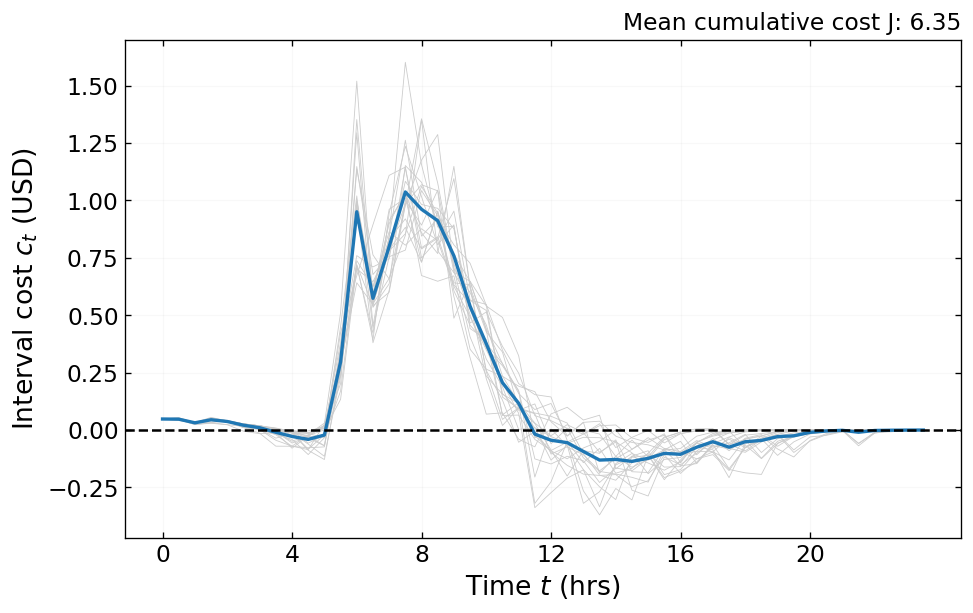

In [6]:
plot_state_trajectories(history)
plot_control_trajectories(history)
plot_endogenous_trajectories(history)
plot_cost_trajectories(history)